# 2026 FIFA World Cup Bracket Prediction Notebook

This notebook builds a transparent, reproducible prediction for the 2026 FIFA World Cup from group stage through the final, using information available as of **2026-04-29**.

The prediction is intentionally a lightweight model rather than a betting model. It combines FIFA ranking position, host advantage, squad depth, and a qualitative player-form modifier, then applies that rating to expected group points and knockout win probabilities.

## Sources And Current Uncertainties

Primary/current references used to build the dataset:

- FIFA ranking page: latest official men's ranking update shown as **1 April 2026**, next update **10 June 2026**: https://inside.fifa.com/fifa-world-ranking/men
- ESPN table of the April 2026 FIFA Men's Top 50 plus qualified-team honorable mentions: https://www.espn.com/soccer/story/_/id/46664763/fifa-mens-top-50-world-rankings
- FIFA qualified-team article for the 2026 field: https://www.fifa.com/en/articles/world-cup-2026-who-has-qualified
- FIFA schedule article for the draw and 104-match tournament structure: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/updated-fifa-world-cup-2026-match-schedule-now-available
- Knockout round-of-32 template and Annex C third-place mapping summary: https://football.fandom.com/wiki/2026_FIFA_World_Cup_knockout_stage
- DR Congo playoff placement in Group K after beating Jamaica: https://www.beinsports.com/en-us/soccer/fifa-world-cup-2026/articles/dr-congo-beat-jamaica-to-become-the-47th-team-qualified-for-the-2026-world-cup-2026-03-31

Important caveats:

- Final squads are not yet locked. Injuries, player minutes, late-season club form, and tactical choices can materially change these probabilities.
- Player-form modifiers are hand-scored from recent club/national-team context, not scraped from a live player database. They are documented in the tables below so they can be edited.
- This uses rank position rather than exact FIFA rating points for every team. Exact points would improve calibration, especially among elite teams where ranks are very close.
- The round-of-32 third-place placement uses the official template row matching the model's predicted eight third-place qualifiers.

## Method

For each team, I calculate a rating:

```text
rating = 100 - 0.8 * FIFA_rank + host_bonus + form_modifier + depth_modifier
```

Where:

- `FIFA_rank`: April 2026 FIFA ranking position.
- `host_bonus`: +3 for Mexico and USA, +2 for Canada.
- `form_modifier`: subjective player/team form adjustment from -1 to +4, based on recent club, cup, and national-team context.
- `depth_modifier`: squad-depth bonus based on FIFA rank bucket: +2.0 for top 10, +1.2 for 11-20, +0.6 for 21-30, +0.2 for 31-45, otherwise 0.

For group matches, expected points are based on a logistic win model plus a draw probability:

```text
p_non_draw_team_a = logistic((rating_a - rating_b) / 8)
draw_probability = clipped between 18% and 30%, lower when teams are far apart
expected_points = 3 * win_probability + draw_probability
```

For knockout matches:

```text
win_probability = logistic((rating_a - rating_b) / 8)
```

The model advances the team with the higher win probability in each knockout match.

In [1]:
import math
import textwrap
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 9

## Team Data

The group table below embeds the April 2026 FIFA ranking positions and the adjustment inputs used by this notebook.

In [2]:
teams_data = [
    # group, team, rank, host_bonus, form_modifier, form_note
    ("A", "Mexico", 15, 3, 1.0, "Host lift; strong home-continent conditions; Gimenez/Alvarez/Lozano core gives balance."),
    ("A", "South Africa", 60, 0, 0.0, "Organized but lower attacking ceiling versus group rivals."),
    ("A", "Korea Republic", 25, 0, 0.6, "Son and Kim Min-jae keep the floor high; tournament experience helps."),
    ("A", "Czechia", 41, 0, 0.3, "Schick and Soucek profile well for tight games and set pieces."),

    ("B", "Canada", 30, 2, 0.5, "Host bonus plus Davies/David transition threat; consistency is the swing factor."),
    ("B", "Bosnia and Herzegovina", 65, 0, 0.2, "Dzeko/Pjanic experience, but aging core and lower depth."),
    ("B", "Qatar", 55, 0, 0.0, "Recent tournament experience, but lower ranking and squad depth."),
    ("B", "Switzerland", 19, 0, 0.8, "Xhaka/Akanji spine and reliable tournament structure."),

    ("C", "Brazil", 6, 0, 2.5, "Vinicius/Rodrygo/Alisson-level talent; elite ceiling despite recent volatility."),
    ("C", "Morocco", 8, 0, 2.0, "Top African side by ranking; Hakimi/Bounou/Brahim Diaz quality and 2022 pedigree."),
    ("C", "Haiti", 83, 0, 0.0, "Historic qualification, but toughest group-strength gap."),
    ("C", "Scotland", 43, 0, 0.3, "Physical midfield and set-piece threat; needs points from Haiti match."),

    ("D", "USA", 16, 3, 0.0, "Host boost and high athletic ceiling; attacking consistency remains the key question."),
    ("D", "Paraguay", 40, 0, 0.5, "Strong defensive edge from CONMEBOL qualifying context."),
    ("D", "Australia", 27, 0, 0.4, "Experienced, physical, hard to eliminate in tournament settings."),
    ("D", "Turkiye", 22, 0, 1.5, "Calhanoglu/Guler/Yildiz give high technical upside."),

    ("E", "Germany", 10, 0, 2.5, "Musiala/Wirtz/Kimmich core and deep club-level quality."),
    ("E", "Curacao", 82, 0, 0.0, "Debut story; rank gap is steep."),
    ("E", "Cote d'Ivoire", 34, 0, 1.0, "AFCON-winning quality still matters; athletic, dangerous third-place candidate."),
    ("E", "Ecuador", 23, 0, 1.0, "Caicedo/Hincapie/W. Pacho spine and strong defensive profile."),

    ("F", "Netherlands", 7, 0, 2.0, "Van Dijk/Gakpo/Simons plus high-end defensive depth."),
    ("F", "Japan", 18, 0, 1.5, "Kubo/Mitoma/Endo technical level and cohesive national-team style."),
    ("F", "Sweden", 38, 0, 1.2, "Isak/Gyokeres/Kulusevski attacking names lift the upside."),
    ("F", "Tunisia", 44, 0, 0.1, "Compact but lower chance-creation profile."),

    ("G", "Belgium", 9, 0, 1.5, "De Bruyne/Doku/Lukaku attacking tools; transition from golden generation still a risk."),
    ("G", "Egypt", 29, 0, 1.0, "Salah keeps them dangerous in single games."),
    ("G", "Iran", 21, 0, 0.1, "Experienced core and solid ranking; attacking variance caps ceiling."),
    ("G", "New Zealand", 85, 0, 0.0, "Big underdog by ranking and depth."),

    ("H", "Spain", 2, 0, 4.0, "Euro-winning core; Yamal/Pedri/Rodri-level midfield and wing talent."),
    ("H", "Cabo Verde", 69, 0, 0.0, "Excellent qualification story, but deep group."),
    ("H", "Saudi Arabia", 61, 0, 0.0, "Tournament experience; needs upset points."),
    ("H", "Uruguay", 17, 0, 2.0, "Valverde/Darwin/Araujo profile gives two-way knockout quality."),

    ("I", "France", 1, 0, 4.0, "No. 1 ranking; Mbappe/Dembele/Olise and unmatched depth."),
    ("I", "Senegal", 14, 0, 1.0, "Mane/N. Jackson/Koulibaly leadership and athleticism."),
    ("I", "Iraq", 57, 0, 0.2, "Playoff momentum, but rank and depth gap in a brutal group."),
    ("I", "Norway", 31, 0, 2.0, "Haaland/Odegaard star power makes them a very strong third-place candidate."),

    ("J", "Argentina", 3, 0, 3.5, "Defending champions; Messi/Lautaro/Julian Alvarez attacking quality."),
    ("J", "Algeria", 28, 0, 0.8, "Mahrez and technical attacking pieces make them a live third-place side."),
    ("J", "Austria", 24, 0, 1.5, "Rangnick-style pressing plus Alaba/Sabitzer leadership."),
    ("J", "Jordan", 63, 0, 0.0, "Historic run, but strong group above them."),

    ("K", "Portugal", 5, 0, 3.0, "Ronaldo/Fernandes/Leao plus deep technical squad."),
    ("K", "DR Congo", 46, 0, 0.2, "Playoff boost and physical profile; lower attacking depth."),
    ("K", "Uzbekistan", 50, 0, 0.1, "Debut team with Shomurodov focal point; narrow third-place path."),
    ("K", "Colombia", 13, 0, 2.0, "Luis Diaz/James/Munoz and strong CONMEBOL profile."),

    ("L", "England", 4, 0, 3.5, "Kane/Bellingham/Saka and elite attacking depth."),
    ("L", "Croatia", 11, 0, 1.0, "Modric/Gvardiol/Kovacic experience and control."),
    ("L", "Ghana", 74, 0, 0.2, "Athletic upside, but rank and depth concerns."),
    ("L", "Panama", 33, 0, 0.2, "Concacaf-tested and organized; third-place route is plausible."),
]

teams = pd.DataFrame(teams_data, columns=["group", "team", "fifa_rank", "host_bonus", "form_modifier", "form_note"])

def depth_modifier(rank):
    if rank <= 10:
        return 2.0
    if rank <= 20:
        return 1.2
    if rank <= 30:
        return 0.6
    if rank <= 45:
        return 0.2
    return 0.0

teams["depth_modifier"] = teams["fifa_rank"].map(depth_modifier)
teams["rating"] = 100 - 0.8 * teams["fifa_rank"] + teams["host_bonus"] + teams["form_modifier"] + teams["depth_modifier"]
teams.sort_values(["group", "rating"], ascending=[True, False]).style.format({"rating": "{:.1f}", "form_modifier": "{:.1f}", "depth_modifier": "{:.1f}"})

,group,team,fifa_rank,host_bonus,form_modifier,form_note,depth_modifier,rating
0,A,Mexico,15,3,1.0,Host lift; strong home-continent conditions; Gimenez/Alvarez/Lozano core gives balance.,1.2,93.2
2,A,Korea Republic,25,0,0.6,Son and Kim Min-jae keep the floor high; tournament experience helps.,0.6,81.2
3,A,Czechia,41,0,0.3,Schick and Soucek profile well for tight games and set pieces.,0.2,67.7
1,A,South Africa,60,0,0.0,Organized but lower attacking ceiling versus group rivals.,0.0,52.0
7,B,Switzerland,19,0,0.8,Xhaka/Akanji spine and reliable tournament structure.,1.2,86.8
4,B,Canada,30,2,0.5,Host bonus plus Davies/David transition threat; consistency is the swing factor.,0.6,79.1
6,B,Qatar,55,0,0.0,"Recent tournament experience, but lower ranking and squad depth.",0.0,56.0
5,B,Bosnia and Herzegovina,65,0,0.2,"Dzeko/Pjanic experience, but aging core and lower depth.",0.0,48.2
8,C,Brazil,6,0,2.5,Vinicius/Rodrygo/Alisson-level talent; elite ceiling despite recent volatility.,2.0,99.7
9,C,Morocco,8,0,2.0,Top African side by ranking; Hakimi/Bounou/Brahim Diaz quality and 2022 pedigree.,2.0,97.6


## Key Players For Predicted Top Teams In Each Group

The table below lists up to three world-class or high-impact players for the model's projected top two teams in every group. I also include a few likely third-place qualifiers where their star quality materially affects the model.

In [3]:
key_players_data = {
    "Mexico": "Santiago Gimenez; Edson Alvarez; Hirving Lozano",
    "Korea Republic": "Son Heung-min; Kim Min-jae; Lee Kang-in",
    "Czechia": "Patrik Schick; Tomas Soucek; Adam Hlozek",
    "Switzerland": "Granit Xhaka; Manuel Akanji; Breel Embolo",
    "Canada": "Alphonso Davies; Jonathan David; Tajon Buchanan",
    "Brazil": "Vinicius Junior; Rodrygo; Alisson",
    "Morocco": "Achraf Hakimi; Yassine Bounou; Brahim Diaz",
    "Scotland": "Andy Robertson; Scott McTominay; John McGinn",
    "USA": "Christian Pulisic; Weston McKennie; Antonee Robinson",
    "Turkiye": "Hakan Calhanoglu; Arda Guler; Kenan Yildiz",
    "Australia": "Mathew Ryan; Harry Souttar; Jackson Irvine",
    "Germany": "Jamal Musiala; Florian Wirtz; Joshua Kimmich",
    "Ecuador": "Moises Caicedo; Piero Hincapie; Willian Pacho",
    "Cote d'Ivoire": "Simon Adingra; Franck Kessie; Sebastien Haller",
    "Netherlands": "Virgil van Dijk; Cody Gakpo; Xavi Simons",
    "Japan": "Takefusa Kubo; Kaoru Mitoma; Wataru Endo",
    "Belgium": "Kevin De Bruyne; Jeremy Doku; Romelu Lukaku",
    "Iran": "Mehdi Taremi; Sardar Azmoun; Alireza Jahanbakhsh",
    "Egypt": "Mohamed Salah; Omar Marmoush; Mostafa Mohamed",
    "Spain": "Lamine Yamal; Pedri; Rodri",
    "Uruguay": "Federico Valverde; Darwin Nunez; Ronald Araujo",
    "France": "Kylian Mbappe; Ousmane Dembele; Michael Olise",
    "Senegal": "Sadio Mane; Nicolas Jackson; Kalidou Koulibaly",
    "Norway": "Erling Haaland; Martin Odegaard; Alexander Sorloth",
    "Argentina": "Lionel Messi; Lautaro Martinez; Julian Alvarez",
    "Austria": "David Alaba; Marcel Sabitzer; Christoph Baumgartner",
    "Algeria": "Riyad Mahrez; Ismael Bennacer; Amine Gouiri",
    "Portugal": "Cristiano Ronaldo; Bruno Fernandes; Rafael Leao",
    "Colombia": "Luis Diaz; James Rodriguez; Daniel Munoz",
    "England": "Harry Kane; Jude Bellingham; Bukayo Saka",
    "Croatia": "Luka Modric; Josko Gvardiol; Mateo Kovacic",
    "Panama": "Adalberto Carrasquilla; Michael Murillo; Jose Fajardo",
}

key_players = pd.DataFrame([{"team": k, "key_players": v} for k, v in key_players_data.items()])
key_players.head()

,team,key_players
0,Mexico,Santiago Gimenez; Edson Alvarez; Hirving Lozano
1,Korea Republic,Son Heung-min; Kim Min-jae; Lee Kang-in
2,Czechia,Patrik Schick; Tomas Soucek; Adam Hlozek
3,Switzerland,Granit Xhaka; Manuel Akanji; Breel Embolo
4,Canada,Alphonso Davies; Jonathan David; Tajon Buchanan


## Group Stage Simulation

This section converts ratings into expected group points. It does not simulate random draws; instead it produces a deterministic expected-points table, which keeps the prediction reproducible.

In [4]:
def logistic(x):
    return 1 / (1 + math.exp(-x))


def group_match_probabilities(rating_a, rating_b):
    diff = rating_a - rating_b
    draw = max(0.18, min(0.30, 0.30 - abs(diff) * 0.004))
    p_a_non_draw = logistic(diff / 8)
    p_a_win = (1 - draw) * p_a_non_draw
    p_b_win = (1 - draw) * (1 - p_a_non_draw)
    return p_a_win, draw, p_b_win


def expected_group_table(team_df):
    rows = []
    for group, sub in team_df.groupby("group", sort=True):
        stats = {team: {"xpts": 0.0, "xgf": 0.0, "xga": 0.0} for team in sub["team"]}
        records = sub.to_dict("records")
        for i in range(len(records)):
            for j in range(i + 1, len(records)):
                a, b = records[i], records[j]
                p_awin, p_draw, p_bwin = group_match_probabilities(a["rating"], b["rating"])
                stats[a["team"]]["xpts"] += 3 * p_awin + p_draw
                stats[b["team"]]["xpts"] += 3 * p_bwin + p_draw
                # Expected-goal proxy for tie-breaking visualization, not literal xG.
                stats[a["team"]]["xgf"] += 1.15 + (a["rating"] - b["rating"]) / 30
                stats[a["team"]]["xga"] += 1.15 + (b["rating"] - a["rating"]) / 30
                stats[b["team"]]["xgf"] += 1.15 + (b["rating"] - a["rating"]) / 30
                stats[b["team"]]["xga"] += 1.15 + (a["rating"] - b["rating"]) / 30
        for team, stat in stats.items():
            base = team_df.loc[team_df["team"] == team].iloc[0]
            rows.append({
                "group": group,
                "team": team,
                "fifa_rank": int(base["fifa_rank"]),
                "rating": base["rating"],
                "xpts": stat["xpts"],
                "xgd": stat["xgf"] - stat["xga"],
                "xgf": stat["xgf"],
                "xga": stat["xga"],
            })
    out = pd.DataFrame(rows)
    out = out.sort_values(["group", "xpts", "xgd", "rating"], ascending=[True, False, False, False])
    out["group_position"] = out.groupby("group").cumcount() + 1
    return out

standings = expected_group_table(teams)
standings_display = standings.copy()
standings_display[["rating", "xpts", "xgd", "xgf", "xga"]] = standings_display[["rating", "xpts", "xgd", "xgf", "xga"]].round(2)
standings_display

,group,team,fifa_rank,rating,xpts,xgd,xgf,xga,group_position
0,A,Mexico,15,93.2,7.22,5.25,6.07,0.83,1
2,A,Korea Republic,25,81.2,5.39,2.05,4.47,2.43,2
3,A,Czechia,41,67.7,3.14,-1.55,2.67,4.23,3
1,A,South Africa,60,52.0,0.96,-5.74,0.58,6.32,4
7,B,Switzerland,19,86.8,7.06,5.14,6.02,0.88,1
4,B,Canada,30,79.1,5.92,3.09,4.99,1.91,2
6,B,Qatar,55,56.0,2.43,-3.07,1.91,4.99,3
5,B,Bosnia and Herzegovina,65,48.2,1.30,-5.15,0.87,6.03,4
8,C,Brazil,6,99.7,6.74,6.79,6.84,0.06,1
9,C,Morocco,8,97.6,6.45,6.23,6.56,0.34,2


In [5]:
# Projected automatic qualifiers and best third-place teams.
auto_qualifiers = standings[standings["group_position"] <= 2].copy()
thirds = standings[standings["group_position"] == 3].copy()
best_thirds = thirds.sort_values(["xpts", "xgd", "rating"], ascending=False).head(8).copy()
best_thirds["third_rank"] = range(1, len(best_thirds) + 1)

print("Projected automatic qualifiers by group:")
display(auto_qualifiers[["group", "group_position", "team", "xpts", "xgd", "rating"]].round(2))

print("Projected best third-place qualifiers:")
display(best_thirds[["third_rank", "group", "team", "xpts", "xgd", "rating"]].round(2))

Projected automatic qualifiers by group:


,group,group_position,team,xpts,xgd,rating
0,A,1,Mexico,7.22,5.25,93.2
2,A,2,Korea Republic,5.39,2.05,81.2
7,B,1,Switzerland,7.06,5.14,86.8
4,B,2,Canada,5.92,3.09,79.1
8,C,1,Brazil,6.74,6.79,99.7
9,C,2,Morocco,6.45,6.23,97.6
12,D,1,USA,6.34,2.77,91.4
15,D,2,Turkiye,4.86,0.93,84.5
16,E,1,Germany,7.23,6.53,96.5
19,E,2,Ecuador,5.18,2.98,83.2


Projected best third-place qualifiers:


,third_rank,group,team,xpts,xgd,rating
25,1,G,Egypt,4.09,1.53,78.4
37,2,J,Algeria,3.99,0.09,79.0
18,3,E,Cote d'Ivoire,3.76,0.53,74.0
14,4,D,Australia,3.71,-0.43,79.4
35,5,I,Norway,3.31,-1.24,77.4
47,6,L,Panama,3.27,-0.98,74.0
3,7,A,Czechia,3.14,-1.55,67.7
11,8,C,Scotland,3.04,-2.17,66.1


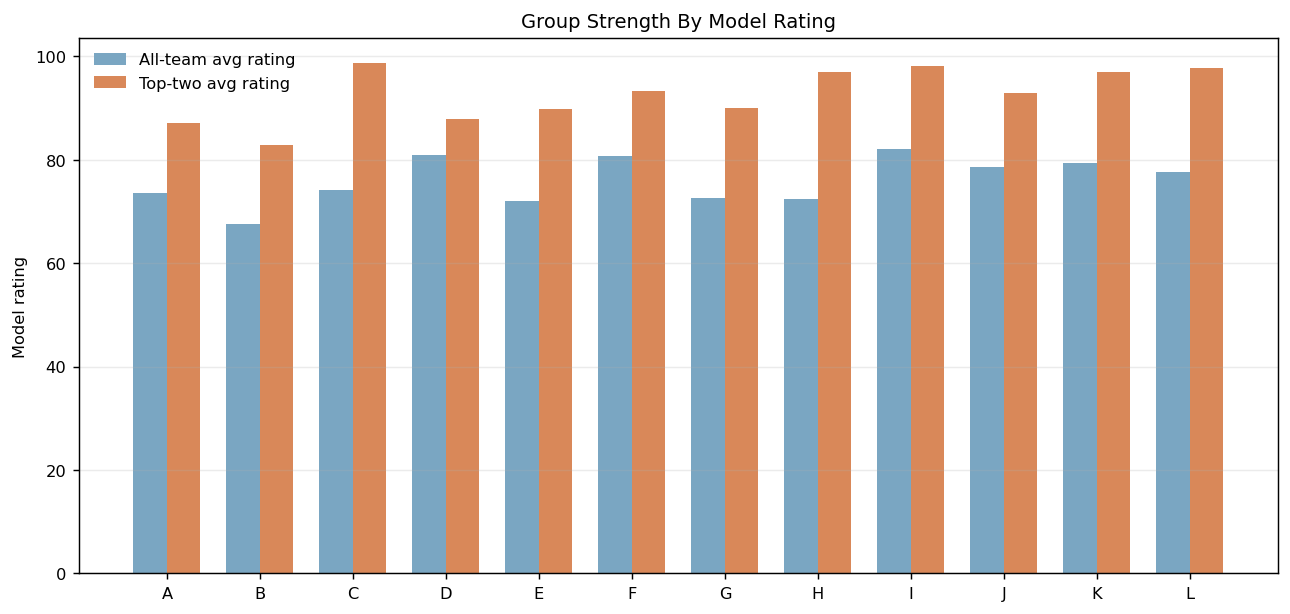

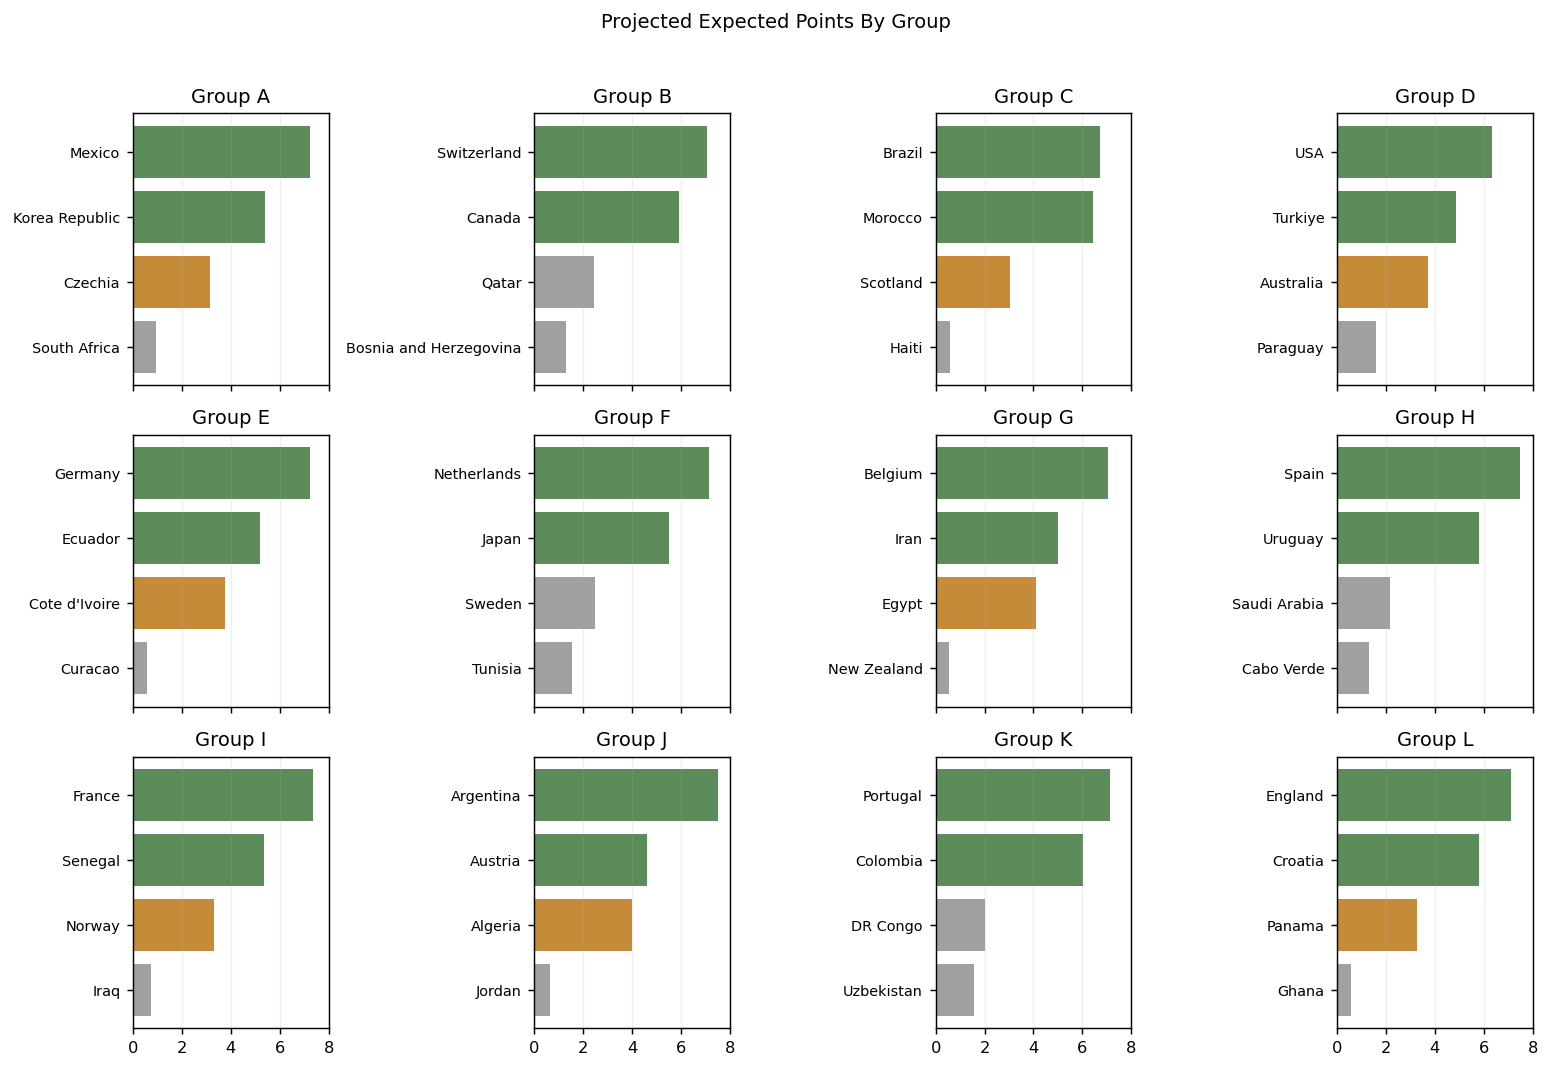

In [6]:
# Group strength visualizations.
group_strength = teams.groupby("group").agg(
    avg_rating=("rating", "mean"),
    top_two_avg=("rating", lambda s: s.sort_values(ascending=False).head(2).mean()),
    max_rating=("rating", "max")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(group_strength))
ax.bar(x - 0.18, group_strength["avg_rating"], width=0.36, label="All-team avg rating", color="#7aa6c2")
ax.bar(x + 0.18, group_strength["top_two_avg"], width=0.36, label="Top-two avg rating", color="#d98859")
ax.set_xticks(x)
ax.set_xticklabels(group_strength["group"])
ax.set_ylabel("Model rating")
ax.set_title("Group Strength By Model Rating")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(12, 8), sharex=True)
axes = axes.ravel()
for ax, (group, sub) in zip(axes, standings.groupby("group")):
    sub = sub.sort_values("xpts")
    colors = ["#5b8c5a" if pos <= 2 else "#c58b39" if team in set(best_thirds["team"]) else "#a0a0a0" for pos, team in zip(sub["group_position"], sub["team"])]
    ax.barh(sub["team"], sub["xpts"], color=colors)
    ax.set_title(f"Group {group}")
    ax.set_xlim(0, 8)
    ax.grid(axis="x", alpha=0.2)
for ax in axes:
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Projected Expected Points By Group", y=1.02)
plt.tight_layout()
plt.show()

## Key Players In The Predicted Advancing Pool

This joins the advancing teams to the key-player notes so it is easy to inspect which star players are driving the qualitative form modifiers.

In [7]:
advancing_pool = pd.concat([auto_qualifiers, best_thirds], ignore_index=True)
advancing_pool = advancing_pool.merge(key_players, on="team", how="left")
advancing_pool = advancing_pool.merge(teams[["team", "form_modifier", "form_note"]], on="team", how="left")
advancing_pool[["group", "group_position", "team", "fifa_rank", "rating", "xpts", "key_players", "form_modifier", "form_note"]].sort_values(["group", "group_position"]).round(2)

,group,group_position,team,fifa_rank,rating,xpts,key_players,form_modifier,form_note
0,A,1,Mexico,15,93.2,7.22,Santiago Gimenez; Edson Alvarez; Hirving Lozano,1.0,Host lift; strong home-continent conditions; Gimenez/Alvarez/Lozano core gives balance.
1,A,2,Korea Republic,25,81.2,5.39,Son Heung-min; Kim Min-jae; Lee Kang-in,0.6,Son and Kim Min-jae keep the floor high; tournament experience helps.
30,A,3,Czechia,41,67.7,3.14,Patrik Schick; Tomas Soucek; Adam Hlozek,0.3,Schick and Soucek profile well for tight games and set pieces.
2,B,1,Switzerland,19,86.8,7.06,Granit Xhaka; Manuel Akanji; Breel Embolo,0.8,Xhaka/Akanji spine and reliable tournament structure.
3,B,2,Canada,30,79.1,5.92,Alphonso Davies; Jonathan David; Tajon Buchanan,0.5,Host bonus plus Davies/David transition threat; consistency is the swing factor.
4,C,1,Brazil,6,99.7,6.74,Vinicius Junior; Rodrygo; Alisson,2.5,Vinicius/Rodrygo/Alisson-level talent; elite ceiling despite recent volatility.
5,C,2,Morocco,8,97.6,6.45,Achraf Hakimi; Yassine Bounou; Brahim Diaz,2.0,Top African side by ranking; Hakimi/Bounou/Brahim Diaz quality and 2022 pedigree.
31,C,3,Scotland,43,66.1,3.04,Andy Robertson; Scott McTominay; John McGinn,0.3,Physical midfield and set-piece threat; needs points from Haiti match.
6,D,1,USA,16,91.4,6.34,Christian Pulisic; Weston McKennie; Antonee Robinson,0.0,Host boost and high athletic ceiling; attacking consistency remains the key question.
7,D,2,Turkiye,22,84.5,4.86,Hakan Calhanoglu; Arda Guler; Kenan Yildiz,1.5,Calhanoglu/Guler/Yildiz give high technical upside.


## Knockout Bracket Construction

The official 2026 format sends each group winner/runner-up plus the best eight third-place teams into a 32-team knockout bracket.

For this model, the predicted third-place qualifiers come from groups **A, C, D, E, G, I, J, L**. The Annex C row for that combination maps third-place opponents as:

```text
1A vs 3E, 1B vs 3G, 1D vs 3J, 1E vs 3C,
1G vs 3A, 1I vs 3D, 1K vs 3L, 1L vs 3I
```

The fixed runner-up matchups are then added from the official bracket template.

In [8]:
# Build lookup dictionaries for group winners, runners-up, and third-place qualifiers.
winners = standings[standings["group_position"] == 1].set_index("group")["team"].to_dict()
runners_up = standings[standings["group_position"] == 2].set_index("group")["team"].to_dict()
third_qualifiers = best_thirds.set_index("group")["team"].to_dict()
third_groups = " ".join(sorted(third_qualifiers))
third_groups

'A C D E G I J L'

In [9]:
# Annex C row used by this scenario: A C D E G I J L.
third_mapping_for_group_winners = {
    "A": "E",
    "B": "G",
    "D": "J",
    "E": "C",
    "G": "A",
    "I": "D",
    "K": "L",
    "L": "I",
}

r32_pairs = OrderedDict([
    (73, (runners_up["A"], runners_up["B"], "2A vs 2B")),
    (74, (winners["E"], third_qualifiers[third_mapping_for_group_winners["E"]], "1E vs 3C")),
    (75, (winners["F"], runners_up["C"], "1F vs 2C")),
    (76, (winners["C"], runners_up["F"], "1C vs 2F")),
    (77, (winners["I"], third_qualifiers[third_mapping_for_group_winners["I"]], "1I vs 3D")),
    (78, (runners_up["E"], runners_up["I"], "2E vs 2I")),
    (79, (winners["A"], third_qualifiers[third_mapping_for_group_winners["A"]], "1A vs 3E")),
    (80, (winners["L"], third_qualifiers[third_mapping_for_group_winners["L"]], "1L vs 3I")),
    (81, (winners["D"], third_qualifiers[third_mapping_for_group_winners["D"]], "1D vs 3J")),
    (82, (winners["G"], third_qualifiers[third_mapping_for_group_winners["G"]], "1G vs 3A")),
    (83, (runners_up["K"], runners_up["L"], "2K vs 2L")),
    (84, (winners["H"], runners_up["J"], "1H vs 2J")),
    (85, (winners["B"], third_qualifiers[third_mapping_for_group_winners["B"]], "1B vs 3G")),
    (86, (winners["J"], runners_up["H"], "1J vs 2H")),
    (87, (winners["K"], third_qualifiers[third_mapping_for_group_winners["K"]], "1K vs 3L")),
    (88, (runners_up["D"], runners_up["G"], "2D vs 2G")),
])

ratings = teams.set_index("team")["rating"].to_dict()

def knockout_win_probability(team_a, team_b):
    return logistic((ratings[team_a] - ratings[team_b]) / 8)


def knockout_result(match, round_name, team_a, team_b, slot):
    p_a = knockout_win_probability(team_a, team_b)
    winner = team_a if p_a >= 0.5 else team_b
    loser = team_b if winner == team_a else team_a
    return {
        "match": match,
        "round": round_name,
        "slot": slot,
        "team_a": team_a,
        "team_b": team_b,
        "win_prob_team_a": p_a,
        "winner": winner,
        "loser": loser,
        "winner_probability": max(p_a, 1 - p_a),
    }

knockout = {}
for match, (a, b, slot) in r32_pairs.items():
    knockout[match] = knockout_result(match, "Round of 32", a, b, slot)

def W(match):
    return knockout[match]["winner"]

r16_pairs = OrderedDict([
    (89, (W(74), W(77), "W74 vs W77")),
    (90, (W(73), W(75), "W73 vs W75")),
    (91, (W(76), W(78), "W76 vs W78")),
    (92, (W(79), W(80), "W79 vs W80")),
    (93, (W(83), W(84), "W83 vs W84")),
    (94, (W(81), W(82), "W81 vs W82")),
    (95, (W(86), W(88), "W86 vs W88")),
    (96, (W(85), W(87), "W85 vs W87")),
])
for match, (a, b, slot) in r16_pairs.items():
    knockout[match] = knockout_result(match, "Round of 16", a, b, slot)

qf_pairs = OrderedDict([
    (97, (W(89), W(90), "W89 vs W90")),
    (98, (W(93), W(94), "W93 vs W94")),
    (99, (W(91), W(92), "W91 vs W92")),
    (100, (W(95), W(96), "W95 vs W96")),
])
for match, (a, b, slot) in qf_pairs.items():
    knockout[match] = knockout_result(match, "Quarterfinal", a, b, slot)

sf_pairs = OrderedDict([
    (101, (W(97), W(98), "W97 vs W98")),
    (102, (W(99), W(100), "W99 vs W100")),
])
for match, (a, b, slot) in sf_pairs.items():
    knockout[match] = knockout_result(match, "Semifinal", a, b, slot)

knockout[103] = knockout_result(103, "Third-place Match", knockout[101]["loser"], knockout[102]["loser"], "L101 vs L102")
knockout[104] = knockout_result(104, "Final", W(101), W(102), "W101 vs W102")

knockout_table = pd.DataFrame(knockout.values()).sort_values("match")
knockout_table["win_prob_team_a"] = knockout_table["win_prob_team_a"].round(3)
knockout_table["winner_probability"] = knockout_table["winner_probability"].round(3)
knockout_table

,match,round,slot,team_a,team_b,win_prob_team_a,winner,loser,winner_probability
0,73,Round of 32,2A vs 2B,Korea Republic,Canada,0.565,Korea Republic,Canada,0.565
1,74,Round of 32,1E vs 3C,Germany,Scotland,0.978,Germany,Scotland,0.978
2,75,Round of 32,1F vs 2C,Netherlands,Morocco,0.525,Netherlands,Morocco,0.525
3,76,Round of 32,1C vs 2F,Brazil,Japan,0.806,Brazil,Japan,0.806
4,77,Round of 32,1I vs 3D,France,Australia,0.962,France,Australia,0.962
5,78,Round of 32,2E vs 2I,Ecuador,Senegal,0.274,Senegal,Ecuador,0.726
6,79,Round of 32,1A vs 3E,Mexico,Cote d'Ivoire,0.917,Mexico,Cote d'Ivoire,0.917
7,80,Round of 32,1L vs 3I,England,Norway,0.957,England,Norway,0.957
8,81,Round of 32,1D vs 3J,USA,Algeria,0.825,USA,Algeria,0.825
9,82,Round of 32,1G vs 3A,Belgium,Czechia,0.973,Belgium,Czechia,0.973


In [10]:
# Compact round-by-round result view.
result_view = knockout_table[["round", "match", "slot", "team_a", "team_b", "winner", "winner_probability"]].copy()
result_view["winner_probability"] = (100 * result_view["winner_probability"]).round(1).astype(str) + "%"
for round_name in ["Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Third-place Match", "Final"]:
    print(f"\n{round_name}")
    display(result_view[result_view["round"] == round_name])


Round of 32


,round,match,slot,team_a,team_b,winner,winner_probability
0,Round of 32,73,2A vs 2B,Korea Republic,Canada,Korea Republic,56.5%
1,Round of 32,74,1E vs 3C,Germany,Scotland,Germany,97.8%
2,Round of 32,75,1F vs 2C,Netherlands,Morocco,Netherlands,52.5%
3,Round of 32,76,1C vs 2F,Brazil,Japan,Brazil,80.6%
4,Round of 32,77,1I vs 3D,France,Australia,France,96.2%
5,Round of 32,78,2E vs 2I,Ecuador,Senegal,Senegal,72.6%
6,Round of 32,79,1A vs 3E,Mexico,Cote d'Ivoire,Mexico,91.7%
7,Round of 32,80,1L vs 3I,England,Norway,England,95.7%
8,Round of 32,81,1D vs 3J,USA,Algeria,USA,82.5%
9,Round of 32,82,1G vs 3A,Belgium,Czechia,Belgium,97.3%



Round of 16


,round,match,slot,team_a,team_b,winner,winner_probability
16,Round of 16,89,W74 vs W77,Germany,France,France,74.8%
17,Round of 16,90,W73 vs W75,Korea Republic,Netherlands,Netherlands,89.6%
18,Round of 16,91,W76 vs W78,Brazil,Senegal,Brazil,74.8%
19,Round of 16,92,W79 vs W80,Mexico,England,England,75.7%
20,Round of 16,93,W83 vs W84,Croatia,Spain,Spain,79.8%
21,Round of 16,94,W81 vs W82,USA,Belgium,Belgium,64.9%
22,Round of 16,95,W86 vs W88,Argentina,Turkiye,Argentina,91.1%
23,Round of 16,96,W85 vs W87,Switzerland,Portugal,Portugal,85.5%



Quarterfinal


...

,round,match,slot,team_a,team_b,winner,winner_probability
28,Semifinal,101,W97 vs W98,France,Spain,France,52.5%
29,Semifinal,102,W99 vs W100,England,Argentina,Argentina,52.5%



Third-place Match


,round,match,slot,team_a,team_b,winner,winner_probability
30,Third-place Match,103,L101 vs L102,Spain,England,Spain,56.5%



Final


,round,match,slot,team_a,team_b,winner,winner_probability
31,Final,104,W101 vs W102,France,Argentina,France,56.5%


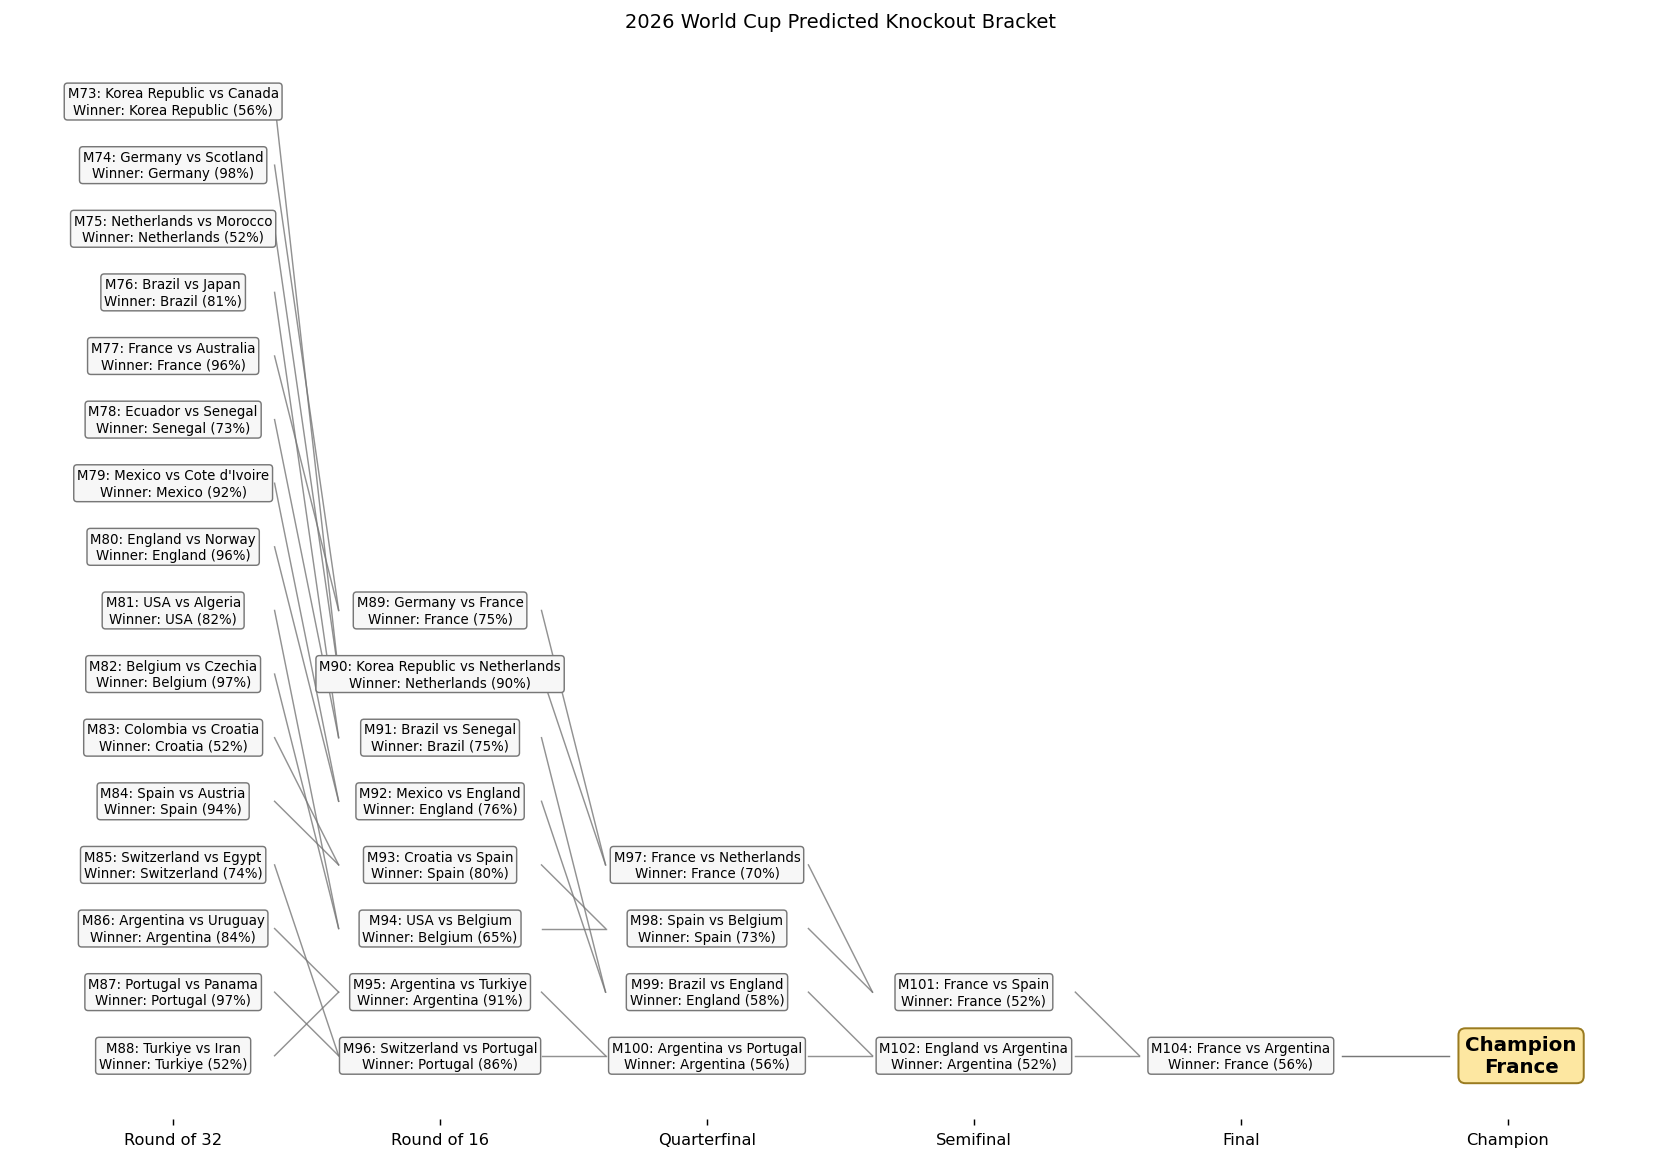

In [11]:
# Bracket visualization. This lays out the deterministic path match-by-match.
round_order = ["Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Final"]
round_x = {name: i for i, name in enumerate(round_order)}

# Fixed y-order follows the official match order in each round.
y_positions = {}
for round_name in round_order:
    matches = knockout_table[knockout_table["round"] == round_name]["match"].tolist()
    n = len(matches)
    for i, match in enumerate(matches):
        y_positions[match] = n - i

# Parent links for bracket tree.
parents = {
    89: [74, 77], 90: [73, 75], 91: [76, 78], 92: [79, 80],
    93: [83, 84], 94: [81, 82], 95: [86, 88], 96: [85, 87],
    97: [89, 90], 98: [93, 94], 99: [91, 92], 100: [95, 96],
    101: [97, 98], 102: [99, 100],
    104: [101, 102],
}

fig, ax = plt.subplots(figsize=(13, 9))
for _, row in knockout_table[knockout_table["round"].isin(round_order)].iterrows():
    x = round_x[row["round"]]
    y = y_positions[row["match"]]
    label = f"M{int(row['match'])}: {row['team_a']} vs {row['team_b']}\nWinner: {row['winner']} ({row['winner_probability']*100:.0f}%)"
    ax.text(x, y, label, ha="center", va="center", fontsize=7.4,
            bbox=dict(boxstyle="round,pad=0.25", fc="#f7f7f7", ec="#777777", lw=0.8))

for child, parent_matches in parents.items():
    child_row = knockout[child]
    child_x = round_x[child_row["round"]]
    child_y = y_positions[child]
    for parent in parent_matches:
        parent_row = knockout[parent]
        parent_x = round_x[parent_row["round"]]
        parent_y = y_positions[parent]
        ax.plot([parent_x + 0.38, child_x - 0.38], [parent_y, child_y], color="#777777", lw=0.8, alpha=0.8)

champion = knockout[104]["winner"]
ax.text(5.05, y_positions[104], f"Champion\n{champion}", ha="center", va="center", fontsize=11, weight="bold",
        bbox=dict(boxstyle="round,pad=0.35", fc="#fde7a1", ec="#9a7b20", lw=1.1))
ax.plot([4.38, 4.78], [y_positions[104], y_positions[104]], color="#777777", lw=0.8)

ax.set_xlim(-0.6, 5.6)
ax.set_ylim(0, 17)
ax.set_xticks(list(round_x.values()) + [5])
ax.set_xticklabels(round_order + ["Champion"])
ax.set_yticks([])
ax.set_title("2026 World Cup Predicted Knockout Bracket")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## Headline Prediction

Based on this model:

- **Champion:** France
- **Runner-up:** Argentina
- **Third place:** Spain
- **Fourth place:** England
- **Semifinals:** France over Spain; Argentina over England
- **Final:** France over Argentina

The tightest elite calls are France vs Spain and England vs Argentina. The model only slightly prefers France and Argentina there because the top national teams are clustered very closely in the April 2026 ranking and because a small player availability change could flip those fixtures.

In [12]:
summary = pd.DataFrame([
    {"result": "Champion", "team": knockout[104]["winner"]},
    {"result": "Runner-up", "team": knockout[104]["loser"]},
    {"result": "Third place", "team": knockout[103]["winner"]},
    {"result": "Fourth place", "team": knockout[103]["loser"]},
])
summary

,result,team
0,Champion,France
1,Runner-up,Argentina
2,Third place,Spain
3,Fourth place,England


## Sensitivity Notes

The most important uncertainty factors to revisit before the tournament starts:

1. **Final squads and injuries:** Rodri, Messi, Ronaldo, Mbappe, Kane, Haaland, Vinicius, and other star availability would noticeably move probabilities.
2. **June 2026 FIFA ranking update:** FIFA's next update is scheduled shortly before the tournament; the top-five order and mid-table ranks can change after late friendlies.
3. **Third-place volatility:** The eight best third-place teams are the hardest bracket input to predict. Small group-stage score swings can change the Annex C mapping and therefore alter the entire knockout route.
4. **Venue/travel/heat:** Host-continent travel and summer conditions likely help Mexico/USA/Canada more than the base rating captures.
5. **Player-form modifiers:** These are transparent subjective inputs. Updating them after late-season club finals and friendlies is the easiest way to refresh the notebook.